# Determining Severity

**Goal of project: Fit models to predict the severity of an attack based on various factors**

Severity: based on number of kills and wounded

# Data Preprocessing

## Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)


## Load Data
Only use data from years 2012+

In [5]:
data = pd.read_csv('globalterrorismdb_0221dist.csv', skiprows=[1], skipinitialspace=True)
data = data[data['iyear'] >= 2012].copy()


## Select Columns

Check null values for initial columns we chose. Only keep columns with null values less than 70%

In [6]:
cols = [
    'iyear', 'imonth', 'iday',
    'country_txt', 'region_txt',
    'attacktype1_txt', 'attacktype2_txt', 'attacktype3_txt',
    'targtype1_txt',   'targtype2_txt',   'targtype3_txt',
    'weaptype1_txt',   'weaptype2_txt',   'weaptype3_txt',
    'gname', 'individual', 'nperps',
    'success', 'extended', 'claimed',
    'ishostkid', 'nhostkid',
    'INT_ANY',
    'nkill', 'nwound',
    'property', 'propextent_txt',
]

df = data[cols].copy()

null_rates = (df.isnull().mean() * 100).sort_values(ascending=False)
print(null_rates)

attacktype3_txt    99.603722
targtype3_txt      99.119267
weaptype3_txt      98.454309
attacktype2_txt    94.989471
nhostkid           91.354503
targtype2_txt      90.878347
weaptype2_txt      90.326462
propextent_txt     64.716744
nwound              9.350913
nkill               5.621544
iday                0.000000
targtype1_txt       0.000000
country_txt         0.000000
region_txt          0.000000
attacktype1_txt     0.000000
imonth              0.000000
iyear               0.000000
weaptype1_txt       0.000000
gname               0.000000
extended            0.000000
success             0.000000
nperps              0.000000
individual          0.000000
INT_ANY             0.000000
ishostkid           0.000000
claimed             0.000000
property            0.000000
dtype: float64


Check remaining columns unique values to check for other null/unknown values. Documentation says that -9, -99, and Unknown are all present as missing/unknown data.

Notes:
gname: 46.5% unknown (A lot)
nperps: 82% missing - remove

In [7]:
cols = [
    'iyear', 'imonth', 'iday',
    'country_txt', 'region_txt',
    'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt',
    'gname', 'individual', 'nperps',
    'success', 'extended', 'claimed',
    'ishostkid',
    'property',
    'nkill', 'nwound',
]

df = data[cols].copy()

for col in df.columns:
    total = len(df[col])
    null_count = df[col].isna().sum()
    if df[col].dtype == 'object':
        unknown_count = (df[col] == 'Unknown').sum()
        neg99_count, neg9_count = 0, 0
    else:
        unknown_count = 0
        neg99_count = (df[col] == -99).sum()
        neg9_count  = (df[col] == -9).sum()
    print(f"{col}:")
    print(f"  Total:     {total:,}")
    print(f"  Null:      {null_count:,}")
    print(f"  'Unknown': {unknown_count:,}")
    print(f"  -99:       {neg99_count:,}")
    print(f"  -9:        {neg9_count:,}")
    print(f"  Null / Total: {((null_count + unknown_count + neg99_count + neg9_count) / total) * 100}\n")

iyear:
  Total:     96,397
  Null:      0
  'Unknown': 0
  -99:       0
  -9:        0
  Null / Total: 0.0

imonth:
  Total:     96,397
  Null:      0
  'Unknown': 0
  -99:       0
  -9:        0
  Null / Total: 0.0

iday:
  Total:     96,397
  Null:      0
  'Unknown': 0
  -99:       0
  -9:        0
  Null / Total: 0.0

country_txt:
  Total:     96,397
  Null:      0
  'Unknown': 0
  -99:       0
  -9:        0
  Null / Total: 0.0

region_txt:
  Total:     96,397
  Null:      0
  'Unknown': 0
  -99:       0
  -9:        0
  Null / Total: 0.0

attacktype1_txt:
  Total:     96,397
  Null:      0
  'Unknown': 6,174
  -99:       0
  -9:        0
  Null / Total: 6.404763633723041

targtype1_txt:
  Total:     96,397
  Null:      0
  'Unknown': 5,629
  -99:       0
  -9:        0
  Null / Total: 5.839393342116455

weaptype1_txt:
  Total:     96,397
  Null:      0
  'Unknown': 9,697
  -99:       0
  -9:        0
  Null / Total: 10.05944168386983

gname:
  Total:     96,397
  Null:      0
  '

Final columns I am keeping:

In [44]:
cols = [
    'iyear', 'imonth', 'iday',
    'country_txt', 'region_txt',
    'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt',
    'individual',
    'success', 'extended', 'claimed',
    'ishostkid',
    'property',
    'nkill', 'nwound'
]
df = data[cols].copy()


NOTES: something to check, how does keeping or removing data with addnotes affect data?

## Clean Data

Replace or drop null values

In [45]:
# 18% unknown (-9)
df['property']  = df['property'].replace(-9, np.nan).fillna(0).astype(int)

# 0.44% unknown - can drop
df['ishostkid'] = df['ishostkid'].replace(-9, np.nan)
df = df.dropna(subset=['ishostkid'])
df['ishostkid'] = df['ishostkid'].astype(int)

# About 10% null, since target value we should drop to preserve data integrity
df = df.dropna(subset=['nkill', 'nwound'])


Final clean data

In [46]:
print(df.isnull().sum())
print(f"\nFinal dataset: {len(df):,} rows, {df.shape[1]} columns")

iyear              0
imonth             0
iday               0
country_txt        0
region_txt         0
attacktype1_txt    0
targtype1_txt      0
weaptype1_txt      0
individual         0
success            0
extended           0
claimed            0
ishostkid          0
property           0
nkill              0
nwound             0
dtype: int64

Final dataset: 86,757 rows, 16 columns


Check variable types. All text/categorical columns need to be encoded

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86757 entries, 104785 to 201181
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iyear            86757 non-null  int64  
 1   imonth           86757 non-null  int64  
 2   iday             86757 non-null  int64  
 3   country_txt      86757 non-null  object 
 4   region_txt       86757 non-null  object 
 5   attacktype1_txt  86757 non-null  object 
 6   targtype1_txt    86757 non-null  object 
 7   weaptype1_txt    86757 non-null  object 
 8   individual       86757 non-null  int64  
 9   success          86757 non-null  int64  
 10  extended         86757 non-null  int64  
 11  claimed          86757 non-null  float64
 12  ishostkid        86757 non-null  int64  
 13  property         86757 non-null  int64  
 14  nkill            86757 non-null  float64
 15  nwound           86757 non-null  float64
dtypes: float64(3), int64(8), object(5)
memory usage: 11.3+ MB

There are 151 unique countries. Before encoding, checking how to use country column.

In [48]:
for num_country in [10,15,20,25]:
    top_x_country_attacks = df['country_txt'].value_counts().head(num_country).sum() / len(df)
    print(f"Top {num_country} countries account for {top_x_country_attacks:.2%} of all attacks")

df['country_txt'].value_counts().head(15)

Top 10 countries account for 74.31% of all attacks
Top 15 countries account for 83.89% of all attacks
Top 20 countries account for 88.65% of all attacks
Top 25 countries account for 91.96% of all attacks


,count
country_txt,
Iraq,17837
Afghanistan,12183
Pakistan,9376
India,6247
Philippines,4423
Yemen,4091
Nigeria,3100
Somalia,2851
Thailand,2260


Based on above, best to use top 15 countries and put all others in Other.

In [49]:
top_countries = df['country_txt'].value_counts().head(15).index
df['country_grouped'] = df['country_txt'].where(df['country_txt'].isin(top_countries), other='Other')
# drop country_txt since we dont need to use it anymore
df = df.drop(columns=['country_txt'])

## Prepare features and target data

Get train and test splits

In [40]:
random_state = 42

# All features except target columns
X = df.drop(columns=['nkill', 'nwound'])

# Target values
y = np.column_stack([
    np.log1p(df['nkill']),
    np.log1p(df['nwound'])
])

# Train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)


Encode categorical variables. Scale numerical columns.

Added scaling for the linear and ridge models

In [41]:
cat_cols = ['country_grouped', 'region_txt', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt']
num_cols = ['iyear', 'imonth', 'iday', 'individual', 'success', 'extended', 'claimed', 'ishostkid', 'property']

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ("num", StandardScaler(), num_cols)
])

# Models

## Try 1 - severity score

prepare models and pipeline

(preprocess previously defined in data preprocessing)

In [17]:
# pip install lightgbm xgboost
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso


base_models = {
    "Ridge"       : Ridge(),
    "Lasso"       : Lasso(),
    "RandomForest": RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1),
    "XGBoost"     : XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    "LightGBM"    : LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
}

pipelines = {
    name: Pipeline([
        ("prep",  preprocess),
        ("model", MultiOutputRegressor(model))
    ])
    for name, model in base_models.items()
}

Train and Evaluate

In [18]:
from tqdm import tqdm

for name, pipe in tqdm(pipelines.items(), desc="Training models", unit="model"):
    print(f"\nTraining {name}...")
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    # Reverse log transform
    nkill_pred  = np.expm1(preds[:, 0])
    nwound_pred = np.expm1(preds[:, 1])
    nkill_true  = np.expm1(y_test[:, 0])
    nwound_true = np.expm1(y_test[:, 1])

    # Per-target metrics
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  nkill  — RMSE: {np.sqrt(mean_squared_error(nkill_true, nkill_pred)):.3f} | R2: {r2_score(nkill_true, nkill_pred):.3f}")
    print(f"  nwound — RMSE: {np.sqrt(mean_squared_error(nwound_true, nwound_pred)):.3f} | R2: {r2_score(nwound_true, nwound_pred):.3f}")

    # Weighted severity score
    severity_pred = 2 * nkill_pred + nwound_pred
    severity_true = 2 * nkill_true + nwound_true
    print(f"  severity (2*kill+wound) — RMSE: {np.sqrt(mean_squared_error(severity_true, severity_pred)):.3f} | R2: {r2_score(severity_true, severity_pred):.3f}")

Training models:   0%|          | 0/5 [00:00<?, ?model/s]


Training Ridge...


Training models:  20%|██        | 1/5 [00:02<00:09,  2.28s/model]


  Ridge
  nkill  — RMSE: 5.698 | R2: 0.034
  nwound — RMSE: 9.815 | R2: 0.019
  severity (2*kill+wound) — RMSE: 18.290 | R2: 0.019

Training Lasso...


Training models:  40%|████      | 2/5 [00:02<00:03,  1.29s/model]

...


  RandomForest
  nkill  — RMSE: 5.543 | R2: 0.086
  nwound — RMSE: 9.023 | R2: 0.171
  severity (2*kill+wound) — RMSE: 17.185 | R2: 0.134

Training XGBoost...


Training models:  80%|████████  | 4/5 [13:29<03:43, 223.71s/model]


  XGBoost
  nkill  — RMSE: 5.494 | R2: 0.102
  nwound — RMSE: 9.419 | R2: 0.097
  severity (2*kill+wound) — RMSE: 17.565 | R2: 0.095

Training LightGBM...


Training models: 100%|██████████| 5/5 [13:31<00:00, 162.31s/model]


  LightGBM
  nkill  — RMSE: 5.546 | R2: 0.085
  nwound — RMSE: 9.549 | R2: 0.072
  severity (2*kill+wound) — RMSE: 17.776 | R2: 0.073


## Try 2 - severity categories

In [28]:
def severity_label(row):
    total = 2 * row['nkill'] + row['nwound']
    if total == 0:    return 0  # No casualties
    elif total <= 5:  return 1  # Low
    elif total <= 20: return 2  # Medium
    else:             return 3  # High

df['severity_class'] = df.apply(severity_label, axis=1)

# Check class distribution
print(df['severity_class'].value_counts())
print(df['severity_class'].value_counts(normalize=True).mul(100).round(1))

severity_class
1    32963
0    28205
2    19449
3     6140
Name: count, dtype: int64
severity_class
1    38.0
0    32.5
2    22.4
3     7.1
Name: proportion, dtype: float64


In [29]:
X = df.drop(columns=['nkill', 'nwound', 'severity_class'])
y = df['severity_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

cat_cols = [
    'country_grouped',
    'region_txt',
    'attacktype1_txt',
    'targtype1_txt',
    'weaptype1_txt'
]

num_cols = [
    'iyear', 'imonth', 'iday',
    'individual', 'success',
    'extended', 'claimed',
    'ishostkid', 'property'
]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ("num", StandardScaler(), num_cols)
])

In [30]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

base_models = {
    "LogisticRegression": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=random_state
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=random_state, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        random_state=random_state, n_jobs=-1, verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        random_state=random_state, n_jobs=-1, verbose=-1, class_weight='balanced'
    ),
}

pipelines = {
    name: Pipeline([
        ("prep",  preprocess),
        ("model", model)
    ])
    for name, model in base_models.items()
}

Training models:   0%|          | 0/4 [00:00<?, ?model/s]


Training LogisticRegression...

  LogisticRegression
              precision    recall  f1-score   support

 No Casualty       0.77      0.73      0.74      5641
         Low       0.68      0.50      0.58      6593
      Medium       0.42      0.41      0.42      3890
        High       0.21      0.57      0.30      1228

    accuracy                           0.56     17352
   macro avg       0.52      0.55      0.51     17352
weighted avg       0.62      0.56      0.58     17352



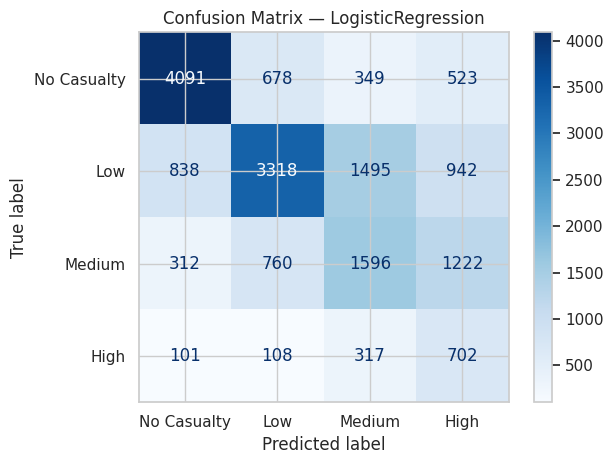

Training models:  25%|██▌       | 1/4 [00:07<00:21,  7.05s/model]


Training RandomForest...

  RandomForest
              precision    recall  f1-score   support

 No Casualty       0.77      0.80      0.78      5641
         Low       0.64      0.68      0.66      6593
      Medium       0.50      0.45      0.47      3890
        High       0.42      0.32      0.36      1228

    accuracy                           0.64     17352
   macro avg       0.58      0.56      0.57     17352
weighted avg       0.63      0.64      0.64     17352



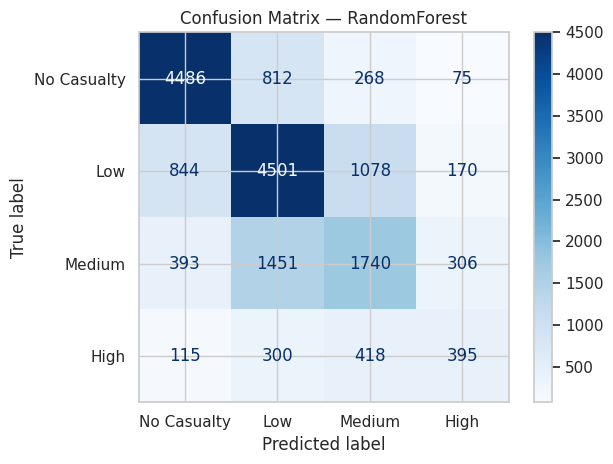

Training models:  50%|█████     | 2/4 [03:32<04:07, 123.86s/model]


Training XGBoost...

  XGBoost
              precision    recall  f1-score   support

 No Casualty       0.78      0.77      0.77      5641
         Low       0.62      0.74      0.67      6593
      Medium       0.51      0.45      0.48      3890
        High       0.51      0.19      0.28      1228

    accuracy                           0.65     17352
   macro avg       0.60      0.54      0.55     17352
weighted avg       0.64      0.65      0.63     17352



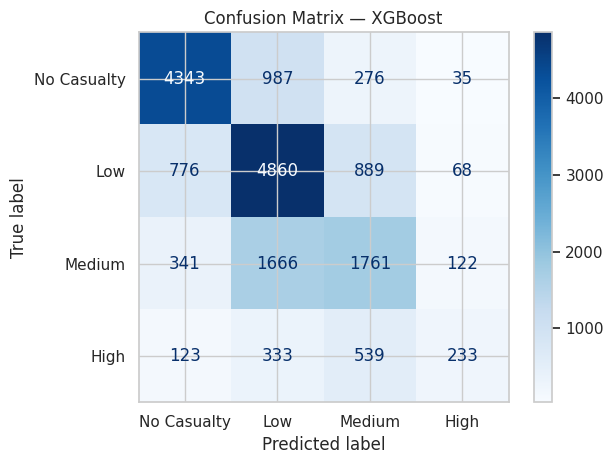

Training models:  75%|███████▌  | 3/4 [03:36<01:09, 69.10s/model] 


Training LightGBM...

  LightGBM
              precision    recall  f1-score   support

 No Casualty       0.79      0.75      0.77      5641
         Low       0.69      0.58      0.63      6593
      Medium       0.48      0.37      0.42      3890
        High       0.24      0.67      0.35      1228

    accuracy                           0.59     17352
   macro avg       0.55      0.59      0.54     17352
weighted avg       0.64      0.59      0.61     17352



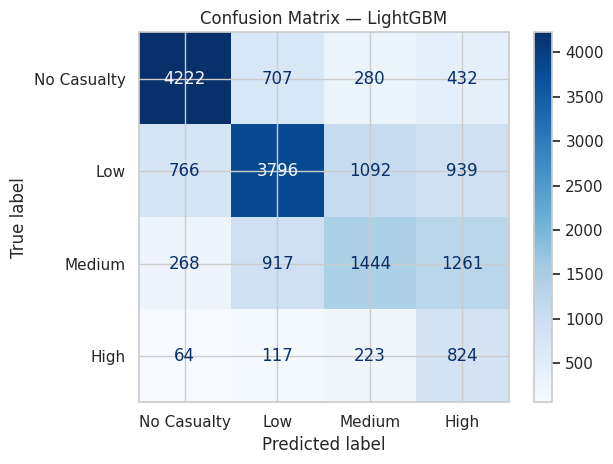

Training models: 100%|██████████| 4/4 [03:40<00:00, 55.03s/model]


In [31]:
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

for name, pipe in tqdm(pipelines.items(), desc="Training models", unit="model"):
    print(f"\nTraining {name}...")
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(
        y_test, preds,
        target_names=['No Casualty', 'Low', 'Medium', 'High']
    ))

    # Confusion matrix
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Casualty', 'Low', 'Medium', 'High']
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

random forest did best, tune hyperparams

In [32]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__n_estimators':     [100, 200, 300],
    'model__max_depth':        [5, 10, 20, None],
    'model__min_samples_split':[2, 5, 10],
    'model__max_features':     ['sqrt', 'log2'],
    'model__class_weight':     ['balanced', 'balanced_subsample']
}

search = RandomizedSearchCV(
    pipelines['RandomForest'],
    param_dist,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best macro F1:", search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__class_weight': 'balanced_subsample'}
Best macro F1: 0.5751148137573275


              precision    recall  f1-score   support

 No Casualty       0.78      0.80      0.79      5641
         Low       0.69      0.63      0.66      6593
      Medium       0.50      0.48      0.49      3890
        High       0.34      0.50      0.41      1228

    accuracy                           0.64     17352
   macro avg       0.58      0.60      0.59     17352
weighted avg       0.65      0.64      0.64     17352



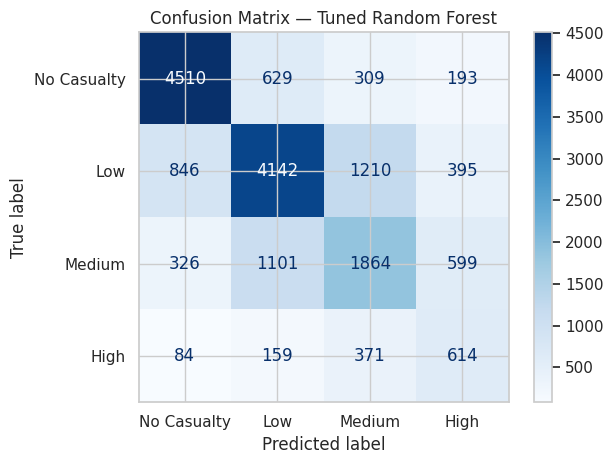

In [33]:
# Use best params and predict
best_model = search.best_estimator_

preds = best_model.predict(X_test)

print(classification_report(
    y_test, preds,
    target_names=['No Casualty', 'Low', 'Medium', 'High']
))

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Casualty', 'Low', 'Medium', 'High']
)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Tuned Random Forest')
plt.tight_layout()
plt.show()

## Try 3 - Try again after removing outliers

severity classification - no improvement

most likely bc classification already sorts severity into buckets so changing getting rid of outliers doesn't really change anything since the buckets are still basically the same

Outlier threshold (99.7th percentile): 146.0
Rows removed: 260
severity_class
1    32963
0    28205
2    19449
3     5880
Name: count, dtype: int64
severity_class
1    38.1
0    32.6
2    22.5
3     6.8
Name: proportion, dtype: float64


Training models:   0%|          | 0/4 [00:00<?, ?model/s]


Training LogisticRegression...

  LogisticRegression
              precision    recall  f1-score   support

 No Casualty       0.77      0.73      0.75      5641
         Low       0.68      0.50      0.58      6593
      Medium       0.42      0.41      0.41      3890
        High       0.20      0.57      0.29      1176

    accuracy                           0.56     17300
   macro avg       0.52      0.55      0.51     17300
weighted avg       0.62      0.56      0.58     17300



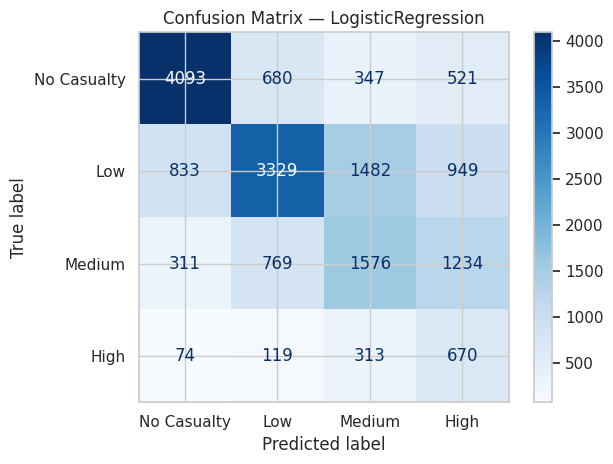

Training models:  25%|██▌       | 1/4 [00:05<00:15,  5.13s/model]


Training RandomForest...

  RandomForest
              precision    recall  f1-score   support

 No Casualty       0.77      0.80      0.78      5641
         Low       0.64      0.68      0.66      6593
      Medium       0.50      0.45      0.48      3890
        High       0.40      0.29      0.33      1176

    accuracy                           0.64     17300
   macro avg       0.58      0.56      0.56     17300
weighted avg       0.63      0.64      0.64     17300



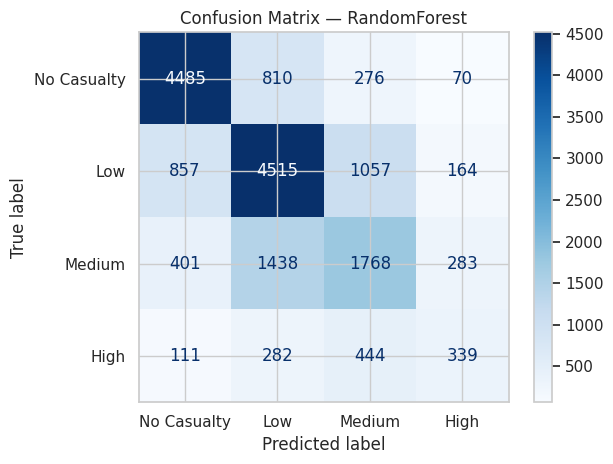

Training models:  50%|█████     | 2/4 [03:23<03:57, 118.59s/model]


Training XGBoost...

  XGBoost
              precision    recall  f1-score   support

 No Casualty       0.78      0.77      0.78      5641
         Low       0.62      0.74      0.68      6593
      Medium       0.51      0.46      0.48      3890
        High       0.49      0.17      0.25      1176

    accuracy                           0.65     17300
   macro avg       0.60      0.53      0.55     17300
weighted avg       0.64      0.65      0.64     17300



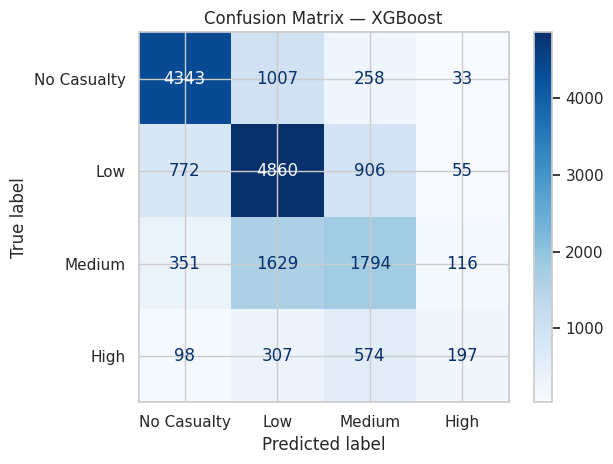

Training models:  75%|███████▌  | 3/4 [03:27<01:06, 66.27s/model] 


Training LightGBM...

  LightGBM
              precision    recall  f1-score   support

 No Casualty       0.79      0.75      0.77      5641
         Low       0.69      0.57      0.62      6593
      Medium       0.47      0.37      0.41      3890
        High       0.22      0.65      0.33      1176

    accuracy                           0.59     17300
   macro avg       0.54      0.58      0.53     17300
weighted avg       0.64      0.59      0.60     17300



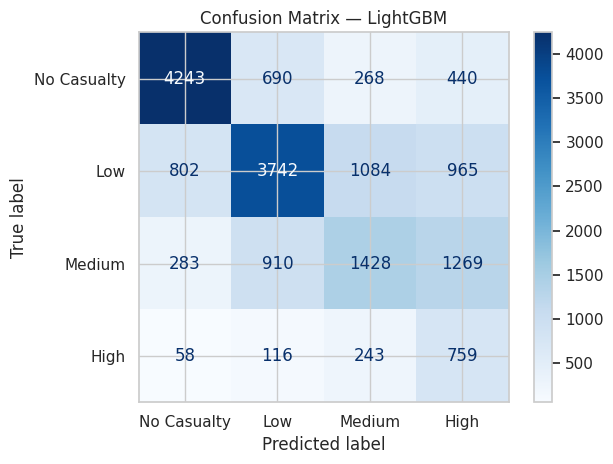

Training models: 100%|██████████| 4/4 [03:33<00:00, 53.27s/model]


In [50]:
# Remove outliers - classification
df['violence_level'] = 2 * df['nkill'] + df['nwound']

p = 0.997
threshold = df['violence_level'].quantile(p)
print(f"Outlier threshold ({p*100}th percentile): {threshold:.1f}")
print(f"Rows removed: {(df['violence_level'] > threshold).sum()}")

df_no_outliers = df[df['violence_level'] <= threshold].copy()


def severity_label(row):
    total = row['violence_level']
    if total == 0:    return 0  # No casualties
    elif total <= 5:  return 1  # Low
    elif total <= 20: return 2  # Medium
    else:             return 3  # High

df_no_outliers['severity_class'] = df_no_outliers.apply(severity_label, axis=1)

print(df_no_outliers['severity_class'].value_counts())
print(df_no_outliers['severity_class'].value_counts(normalize=True).mul(100).round(1))


X = df_no_outliers.drop(columns=['nkill', 'nwound', 'severity_class', 'violence_level'])
y = df_no_outliers['severity_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state, stratify=y
)


cat_cols = ['country_grouped', 'region_txt', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt']
num_cols = ['iyear', 'imonth', 'iday', 'individual', 'success', 'extended', 'claimed', 'ishostkid', 'property']

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ("num", StandardScaler(), num_cols)
])


base_models = {
    "LogisticRegression": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=random_state
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=random_state, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        random_state=random_state, n_jobs=-1, verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        random_state=random_state, n_jobs=-1, verbose=-1, class_weight='balanced'
    ),
}

pipelines = {
    name: Pipeline([("prep", preprocess), ("model", model)])
    for name, model in base_models.items()
}


for name, pipe in tqdm(pipelines.items(), desc="Training models", unit="model"):
    print(f"\nTraining {name}...")
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, preds, target_names=['No Casualty', 'Low', 'Medium', 'High']))

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Casualty', 'Low', 'Medium', 'High'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

severity scores - much better results! R^2 nearly doubles and RMSE goes down by about 6 points.

Random Forest still best result

In [51]:
df['violence_level'] = 2 * df['nkill'] + df['nwound']
df_reg_no_outliers = df[df['violence_level'] <= df['violence_level'].quantile(0.997)].copy()
df_reg_no_outliers = df_reg_no_outliers.drop(columns=['violence_level'])

X = df_reg_no_outliers.drop(columns=['nkill', 'nwound'])
y = np.column_stack([
    np.log1p(df_reg_no_outliers['nkill']),
    np.log1p(df_reg_no_outliers['nwound'])
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

base_models = {
    "Ridge"       : Ridge(),
    "Lasso"       : Lasso(),
    "RandomForest": RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1),
    "XGBoost"     : XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    "LightGBM"    : LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
}

pipelines = {
    name: Pipeline([("prep", preprocess), ("model", MultiOutputRegressor(model))])
    for name, model in base_models.items()
}

for name, pipe in tqdm(pipelines.items(), desc="Training models", unit="model"):
    print(f"\nTraining {name}...")
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    nkill_pred  = np.expm1(preds[:, 0])
    nwound_pred = np.expm1(preds[:, 1])
    nkill_true  = np.expm1(y_test[:, 0])
    nwound_true = np.expm1(y_test[:, 1])

    severity_pred = 2 * nkill_pred + nwound_pred
    severity_true = 2 * nkill_true + nwound_true

    print(f"\n{'='*40}\n  {name}\n{'='*40}")
    print(f"  nkill    — RMSE: {np.sqrt(mean_squared_error(nkill_true, nkill_pred)):.3f} | R2: {r2_score(nkill_true, nkill_pred):.3f}")
    print(f"  nwound   — RMSE: {np.sqrt(mean_squared_error(nwound_true, nwound_pred)):.3f} | R2: {r2_score(nwound_true, nwound_pred):.3f}")
    print(f"  severity — RMSE: {np.sqrt(mean_squared_error(severity_true, severity_pred)):.3f} | R2: {r2_score(severity_true, severity_pred):.3f}")

Training models:   0%|          | 0/5 [00:00<?, ?model/s]


Training Ridge...


Training models:  20%|██        | 1/5 [00:03<00:14,  3.72s/model]


  Ridge
  nkill    — RMSE: 3.947 | R2: 0.071
  nwound   — RMSE: 6.344 | R2: 0.039
  severity — RMSE: 12.089 | R2: 0.049

Training Lasso...


Training models:  40%|████      | 2/5 [00:05<00:07,  2.36s/model]

...


  RandomForest
  nkill    — RMSE: 3.661 | R2: 0.201
  nwound   — RMSE: 5.788 | R2: 0.200
  severity — RMSE: 11.023 | R2: 0.210

Training XGBoost...


Training models:  80%|████████  | 4/5 [13:34<03:44, 224.73s/model]


  XGBoost
  nkill    — RMSE: 3.777 | R2: 0.150
  nwound   — RMSE: 6.001 | R2: 0.140
  severity — RMSE: 11.487 | R2: 0.142

Training LightGBM...


Training models: 100%|██████████| 5/5 [13:38<00:00, 163.77s/model]


  LightGBM
  nkill    — RMSE: 3.828 | R2: 0.126
  nwound   — RMSE: 6.074 | R2: 0.119
  severity — RMSE: 11.647 | R2: 0.118
